# 03D - 03B Acoustic Expert + 03C Text Expert Fusion

Notebook này kiểm tra hướng mới:

```text
03B acoustic/co-attention expert output
        +
03C transcript/text expert output đã train
        ->
fold-safe expert fusion / stacking head
        ->
emotion classification + VAD regression
```

Khác với notebook 03D reproduce paper 2024 cũ, bản này **không train lại raw speech backbone hoặc text backbone**. Nó chỉ dùng output đã export từ 03B và 03C, nên chạy nhanh hơn và phù hợp để kiểm tra giả thuyết:

> Text branch 03C đã tune có bổ sung được cho 03B acoustic branch không?


## Cần upload gì lên Kaggle?

Notebook này không cần checkpoint model nếu bạn chỉ muốn fusion.

### Bắt buộc

1. Output 03B acoustic expert có thư mục:

```text
fusion_features/
  5fold_session_fold_*_train_coattention_features.npz
  5fold_session_fold_*_val_coattention_features.npz
  5fold_session_fold_*_test_coattention_features.npz
```

Nếu muốn chạy **10-fold fusion**, có hai cách:

- Nếu đã có output 03B 10-fold thì upload thêm:

```text
fusion_features/
  10fold_speaker_fold_*_train_coattention_features.npz
  10fold_speaker_fold_*_val_coattention_features.npz
  10fold_speaker_fold_*_test_coattention_features.npz
```

- Nếu chưa có output 03B 10-fold thì upload output notebook 02 để 03D tự train acoustic expert nội bộ:

```text
features/iemocap_full_06d_multibranch_cache.npz
splits/iemocap_10fold_speaker_long.csv
```

2. Output 03C text expert có thư mục:

```text
fusion_features/
  5fold_session_fold_*_train_text_features.npz
  5fold_session_fold_*_val_text_features.npz
  5fold_session_fold_*_test_text_features.npz
  10fold_speaker_fold_*_train_text_features.npz
  10fold_speaker_fold_*_val_text_features.npz
  10fold_speaker_fold_*_test_text_features.npz
```

### Nên upload thêm

```text
reports/
figures/
```

để notebook có thể so sánh với kết quả expert gốc.

### Không cần upload

```text
models/
*.pt
*.pth
*.ckpt
*.safetensors
*.bin
```

Các file model/checkpoint rất nặng và không cần cho 03D nếu đã có `fusion_features`.


<!-- 03D model choice note -->
## L?a ch?n m? h?nh trong notebook 03D

Notebook n?y t?o model head ri?ng cho h??ng **03B acoustic expert + 03C tuned script expert**. ??y kh?ng ph?i 03B freeze g?c; n? l? t?ng fusion nh? h?c t? c?c feature/probability/VAD prediction ?? export c?a 03B v? 03C.

Sau khi ch?y, checkpoint d?ng l?i s? n?m trong `output_03d_03b_03c_expert_fusion/models_acoustic_plus_tuned_script/`, ??ng th?i ???c ??ng g?i v?o `03D_models_acoustic_plus_tuned_script.zip`.


## Nếu 10-fold chưa có output 03B thì làm gì?

Với 10-fold, notebook này có thể **train lại acoustic expert ngay trong 03D** nếu chưa tìm thấy `10fold_speaker_*_coattention_features.npz`.

Luồng chạy lúc đó là:

```text
03D tìm output 03B có sẵn
    -> nếu thiếu 10-fold acoustic features
    -> 03D load cache từ notebook 02
    -> train internal 03B-style acoustic expert trên từng 10-fold
    -> export *_coattention_features.npz

03D load output 03C text expert
    -> fusion 03B acoustic expert + 03C text expert
```

Vì vậy khi chạy 03D đầy đủ, bạn nên upload:

```text
output 02:
  features/iemocap_full_06d_multibranch_cache.npz
  splits/iemocap_10fold_speaker_long.csv

output 03C:
  fusion_features/*_text_features.npz
```

Nếu đã có sẵn output 03B 10-fold thì 03D sẽ dùng luôn, không train lại.


## Vì sao cách này có thể khả quan?

03C text-only cho kết quả classification khá ổn, nhưng VAD arousal/dominance yếu hơn acoustic. Vì vậy hướng tốt nhất không phải thay acoustic bằng text, mà là để text đóng vai trò expert bổ sung:

| Tín hiệu | 03B acoustic/co-attention | 03C transcript text |
|---|---|---|
| Emotion classification | Mạnh hơn text-only | Bổ sung semantics |
| Valence | Tốt, nhưng text có thể hỗ trợ polarity | Khá hữu ích |
| Arousal | Acoustic quan trọng hơn | Text yếu hơn |
| Dominance | Acoustic/prosody quan trọng hơn | Text chỉ bổ trợ |

Notebook này dùng các nhóm feature:

| Nhóm feature | Từ đâu | Vai trò |
|---|---|---|
| `z_acoustic` | 03B `embedding` | Representation acoustic/co-attention |
| `p_acoustic` | 03B `emotion_probs` | Expert confidence của acoustic |
| `vad_acoustic` | 03B `vad_pred` | Expert VAD acoustic |
| `z_text` | 03C `embedding` | Representation transcript |
| `p_text` | 03C `emotion_prob` | Expert confidence của text |
| `vad_text` | 03C `vad_pred_norm` | Expert VAD text |

Fusion head học từ các expert output này, không fine-tune lại 03B/03C.


## Sơ đồ 03D

```mermaid
flowchart LR
    A["03B acoustic expert<br/>embedding + emotion prob + VAD pred"] --> M["Join by train_sample_id / utterance_id"]
    T["03C text expert<br/>embedding + emotion prob + VAD pred"] --> M
    M --> S["StandardScaler fit on train only"]
    S --> F["Lightweight fusion MLP<br/>dropout + residual expert features"]
    F --> H1["Emotion head<br/>4-class"]
    F --> H2["VAD head<br/>valence/arousal/dominance"]
    H1 --> R["WA / UAR / Macro-F1"]
    H2 --> R2["CCC / MAE / RMSE"]
```

Nguyên tắc quan trọng: mỗi fold chỉ dùng output expert của chính fold đó. Train/validation/test không được trộn chéo giữa fold để tránh leakage.


## 03B cũ nên cải thiện gì tiếp?

Vì 03B advanced update hiện chưa thắng 03B bridge cũ, nên hướng tiếp theo nên là **cải thiện có kiểm soát trên 03B cũ**, không thay toàn bộ kiến trúc ngay.

Ưu tiên:

| Mục | Nên làm | Lý do |
|---|---|---|
| 1 | Export 03B cho đủ 10-fold speaker | Muốn so sánh nghiêm túc với 03C/03D phải có cùng protocol |
| 2 | Giữ loss 03B cũ, chỉ tune từng thành phần | Advanced uncertainty loss làm classification giảm |
| 3 | Tăng ablation cho RMM | RMM quá mạnh có thể làm text/acoustic bị mask sai thời điểm |
| 4 | VAD head acoustic-heavy | Arousal/dominance phụ thuộc giọng nói nhiều hơn transcript |
| 5 | Calibration expert probabilities | `emotion_probs` từ expert nên được temperature-calibrate trước khi stacking |
| 6 | Per-dimension VAD loss weight | Valence, arousal, dominance không khó như nhau |
| 7 | Save logits/probs đầy đủ | Fusion sẽ tốt hơn nếu có logits trước softmax thay vì chỉ probability |

Nói ngắn gọn: 03B cũ đang là baseline tốt hơn. Ta nên thêm **text expert fusion** và **calibration/ablation nhỏ**, không nên thay bằng 03B advanced ngay.


In [1]:
import os
import re
import json
import time
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

pd.set_option("display.max_columns", 160)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("CUDA devices:", torch.cuda.device_count())


DEVICE: cuda
CUDA devices: 2


In [2]:
SEED = int(os.getenv("SEED", "42"))
RUN_PROTOCOLS = [x.strip() for x in os.getenv("RUN_PROTOCOLS", "5fold_session,10fold_speaker").split(",") if x.strip()]
MAX_FOLDS = int(os.getenv("MAX_FOLDS", "0"))
ALLOW_TEXT_ONLY_FALLBACK = os.getenv("ALLOW_TEXT_ONLY_FALLBACK", "0") == "1"
AUTO_TRAIN_MISSING_03B_10FOLD = os.getenv("AUTO_TRAIN_MISSING_03B_10FOLD", "1") == "1"

EPOCHS = int(os.getenv("EPOCHS", "80"))
PATIENCE = int(os.getenv("PATIENCE", "12"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "128"))
LR = float(os.getenv("LR", "3e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "1e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.30"))
HIDDEN_DIM = int(os.getenv("HIDDEN_DIM", "384"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.03"))
CE_WEIGHT = float(os.getenv("CE_WEIGHT", "0.40"))
CCC_WEIGHT = float(os.getenv("CCC_WEIGHT", "0.45"))
MSE_WEIGHT = float(os.getenv("MSE_WEIGHT", "0.15"))
PRIMARY_UAR_WEIGHT = float(os.getenv("PRIMARY_UAR_WEIGHT", "0.45"))
PRIMARY_CCC_WEIGHT = float(os.getenv("PRIMARY_CCC_WEIGHT", "0.55"))

ACOUSTIC_EPOCHS = int(os.getenv("ACOUSTIC_EPOCHS", "45"))
ACOUSTIC_PATIENCE = int(os.getenv("ACOUSTIC_PATIENCE", "7"))
ACOUSTIC_BATCH_SIZE = int(os.getenv("ACOUSTIC_BATCH_SIZE", "64"))
ACOUSTIC_LR = float(os.getenv("ACOUSTIC_LR", "4e-4"))
ACOUSTIC_HIDDEN_DIM = int(os.getenv("ACOUSTIC_HIDDEN_DIM", "256"))
ACOUSTIC_DROPOUT = float(os.getenv("ACOUSTIC_DROPOUT", "0.35"))

OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output_03d_03b_03c_expert_fusion")).resolve()
MODEL_VARIANT = os.getenv("MODEL_VARIANT", "03D_acoustic_plus_tuned_script_fusion")
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
PRED_DIR = OUTPUT_DIR / "predictions"
MODEL_DIR = OUTPUT_DIR / "models_acoustic_plus_tuned_script"
INTERNAL_03B_DIR = OUTPUT_DIR / "internal_03b_acoustic"
INTERNAL_03B_FUSION_DIR = INTERNAL_03B_DIR / "fusion_features"
for d in [REPORT_DIR, FIGURE_DIR, PRED_DIR, MODEL_DIR, INTERNAL_03B_DIR, INTERNAL_03B_FUSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print({
    "RUN_PROTOCOLS": RUN_PROTOCOLS,
    "MAX_FOLDS": MAX_FOLDS,
    "ALLOW_TEXT_ONLY_FALLBACK": ALLOW_TEXT_ONLY_FALLBACK,
    "AUTO_TRAIN_MISSING_03B_10FOLD": AUTO_TRAIN_MISSING_03B_10FOLD,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "ACOUSTIC_EPOCHS": ACOUSTIC_EPOCHS,
    "MODEL_VARIANT": MODEL_VARIANT,
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "MODEL_DIR": str(MODEL_DIR),
})


{'RUN_PROTOCOLS': ['5fold_session', '10fold_speaker'], 'MAX_FOLDS': 0, 'ALLOW_TEXT_ONLY_FALLBACK': False, 'AUTO_TRAIN_MISSING_03B_10FOLD': True, 'EPOCHS': 80, 'BATCH_SIZE': 128, 'ACOUSTIC_EPOCHS': 45, 'OUTPUT_DIR': '/kaggle/working/output_03d_03b_03c_expert_fusion'}


In [3]:
LOCAL_PROJECT = Path(r"D:\UTE\Speech Programming\Speech Project")

KAGGLE_DATASET_HINTS = [
    "03b_model",
    "03c_model",
    "output02",
    "output01",
    "iemocap-full-release",
    "iemocapfullrelease",
]

def unique_existing(paths):
    out, seen = [], set()
    for item in paths:
        if not item:
            continue
        p = Path(item)
        if p.exists():
            key = str(p.resolve()).lower()
            if key not in seen:
                seen.add(key)
                out.append(p.resolve())
    return out

def search_roots():
    base = unique_existing([
        os.getenv("EXPERT_FUSION_ROOT"),
        os.getenv("KAGGLE_INPUT_DIR"),
        Path.cwd(),
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        LOCAL_PROJECT,
        LOCAL_PROJECT / "06_w2v_based_models",
    ])
    hinted = []
    for root in base:
        if root.name.lower() in KAGGLE_DATASET_HINTS:
            hinted.append(root)
        for hint in KAGGLE_DATASET_HINTS:
            candidate = root / hint
            if candidate.exists():
                hinted.append(candidate)
    return unique_existing(hinted + base)

def maybe_extract_zips():
    """Allow Kaggle uploads as zip files and extract only relevant 03B/03C/output02 packages."""
    extract_dir = Path("extracted_03d_inputs")
    extract_dir.mkdir(parents=True, exist_ok=True)
    allowed_tokens = [
        "03b", "03c", "output", "fusion", "coattention", "text", "feature", "iemocap"
    ]
    for root in search_roots():
        try:
            zip_files = list(root.rglob("*.zip"))
        except Exception:
            continue
        for zip_path in zip_files:
            lname = zip_path.name.lower()
            if not any(token in lname for token in allowed_tokens):
                continue
            target = extract_dir / zip_path.stem
            marker = target / ".extracted"
            if marker.exists():
                continue
            try:
                target.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(target)
                marker.write_text("ok", encoding="utf-8")
                print("Extracted zip for 03D:", zip_path, "->", target)
            except Exception as exc:
                print("Cannot extract zip:", zip_path, exc)

maybe_extract_zips()

def find_feature_files(kind):
    pattern = "*_coattention_features.npz" if kind == "acoustic" else "*_text_features.npz"
    files = []
    for root in search_roots():
        try:
            files.extend(root.rglob(pattern))
        except Exception:
            pass
    return sorted({p.resolve() for p in files if p.is_file()})

def parse_feature_name(path, kind):
    name = path.name
    suffix = "_coattention_features.npz" if kind == "acoustic" else "_text_features.npz"
    if not name.endswith(suffix):
        return None
    stem = name[:-len(suffix)]
    for split in ["train", "val", "test"]:
        token = f"_{split}"
        if stem.endswith(token):
            fold_full = stem[:-len(token)]
            if fold_full.startswith("5fold_session_"):
                return {"protocol": "5fold_session", "fold": fold_full[len("5fold_session_"):], "split": split, "path": path}
            if fold_full.startswith("10fold_speaker_"):
                return {"protocol": "10fold_speaker", "fold": fold_full[len("10fold_speaker_"):], "split": split, "path": path}
    return None

def build_index(kind):
    index = {}
    rejected = []
    for p in find_feature_files(kind):
        rec = parse_feature_name(p, kind)
        if not rec:
            rejected.append(p)
            continue
        key = (rec["protocol"], rec["fold"])
        previous = index.setdefault(key, {}).get(rec["split"])
        if previous is None or len(str(p)) < len(str(previous)):
            index.setdefault(key, {})[rec["split"]] = rec["path"]
    if rejected:
        print(f"Warning: skipped {len(rejected)} {kind} file(s) because names do not match the expected pattern. Examples:", rejected[:3])
    return index

def protocol_fold_summary(index, name):
    rows = []
    for (protocol, fold), split_map in sorted(index.items()):
        rows.append({
            "source": name,
            "protocol": protocol,
            "fold": fold,
            "has_train": "train" in split_map,
            "has_val": "val" in split_map,
            "has_test": "test" in split_map,
            "complete": all(s in split_map for s in ["train", "val", "test"]),
            "train_path": str(split_map.get("train", "")),
            "val_path": str(split_map.get("val", "")),
            "test_path": str(split_map.get("test", "")),
        })
    return pd.DataFrame(rows)

acoustic_index = build_index("acoustic")
text_index = build_index("text")

print("Search roots:")
for root in search_roots():
    print("-", root)
print("Acoustic expert folds:", len(acoustic_index))
print("Text expert folds:", len(text_index))
print("Acoustic examples:", list(acoustic_index.items())[:2])
print("Text examples:", list(text_index.items())[:2])

acoustic_summary_df = protocol_fold_summary(acoustic_index, "03B acoustic")
text_summary_df = protocol_fold_summary(text_index, "03C text")
display(acoustic_summary_df.groupby(["source", "protocol"])["complete"].agg(["sum", "count"]).reset_index() if len(acoustic_summary_df) else acoustic_summary_df)
display(text_summary_df.groupby(["source", "protocol"])["complete"].agg(["sum", "count"]).reset_index() if len(text_summary_df) else text_summary_df)


Search roots:
- /kaggle/working
- /kaggle/input
Acoustic expert folds: 5
Text expert folds: 15
Acoustic examples: [(('5fold_session', 'fold_1_test_Ses01_val_Ses02'), {'test': PosixPath('/kaggle/input/datasets/linhlaz225/03b-model/03b-coattention-emotion2vec-acoustic-multitask-5fold/fusion_features/5fold_session_fold_1_test_Ses01_val_Ses02_test_coattention_features.npz'), 'train': PosixPath('/kaggle/input/datasets/linhlaz225/03b-model/03b-coattention-emotion2vec-acoustic-multitask-5fold/fusion_features/5fold_session_fold_1_test_Ses01_val_Ses02_train_coattention_features.npz'), 'val': PosixPath('/kaggle/input/datasets/linhlaz225/03b-model/03b-coattention-emotion2vec-acoustic-multitask-5fold/fusion_features/5fold_session_fold_1_test_Ses01_val_Ses02_val_coattention_features.npz')}), (('5fold_session', 'fold_2_test_Ses02_val_Ses03'), {'test': PosixPath('/kaggle/input/datasets/linhlaz225/03b-model/03b-coattention-emotion2vec-acoustic-multitask-5fold/fusion_features/5fold_session_fold_2_test_

,source,protocol,sum,count
0,03B acoustic,5fold_session,5,5


,source,protocol,sum,count
0,03C text,10fold_speaker,10,10
1,03C text,5fold_session,5,5


In [4]:
def find_named_file(filename, required=True):
    env_key = filename.upper().replace(".", "_")
    env_path = os.getenv(env_key, "").strip()
    if env_path and Path(env_path).exists():
        return Path(env_path).resolve()
    for root in search_roots():
        try:
            for p in root.rglob(filename):
                if p.is_file():
                    return p.resolve()
        except Exception:
            pass
    if required:
        roots = "\n".join(f"- {p}" for p in search_roots())
        raise FileNotFoundError(f"Không tìm thấy `{filename}`. Đã quét:\n{roots}")
    return None

def vad_from_df(df):
    if {"valence_norm", "arousal_norm", "dominance_norm"}.issubset(df.columns):
        return df[["valence_norm", "arousal_norm", "dominance_norm"]].astype(np.float32).to_numpy()
    raw = df[["valence", "arousal", "dominance"]].astype(np.float32).to_numpy()
    return np.clip((raw - 1.0) / 4.0, 0.0, 1.0).astype(np.float32)

def raw_vad_from_df(df):
    if {"valence", "arousal", "dominance"}.issubset(df.columns):
        return df[["valence", "arousal", "dominance"]].astype(np.float32).to_numpy()
    norm = vad_from_df(df)
    return norm * 4.0 + 1.0

def ccc_loss_internal(y_true, y_pred, eps=1e-8):
    vx = torch.var(y_true, dim=0, unbiased=False)
    vy = torch.var(y_pred, dim=0, unbiased=False)
    mx = torch.mean(y_true, dim=0)
    my = torch.mean(y_pred, dim=0)
    cov = torch.mean((y_true - mx) * (y_pred - my), dim=0)
    ccc = (2 * cov) / (vx + vy + (mx - my) ** 2 + eps)
    return 1.0 - torch.mean(ccc)

def ccc_np_internal(y_true, y_pred, eps=1e-8):
    out = []
    for i in range(y_true.shape[1]):
        x = y_true[:, i].astype(np.float64)
        y = y_pred[:, i].astype(np.float64)
        mx, my = np.mean(x), np.mean(y)
        vx, vy = np.var(x), np.var(y)
        cov = np.mean((x - mx) * (y - my))
        out.append((2 * cov) / (vx + vy + (mx - my) ** 2 + eps))
    return np.asarray(out, dtype=np.float64)

def acoustic_metrics_internal(y_true, y_pred, vad_true, vad_pred):
    ccc = ccc_np_internal(vad_true, vad_pred)
    return {
        "WA": accuracy_score(y_true, y_pred),
        "UAR": balanced_accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "CCC_mean": float(np.mean(ccc)),
    }

class Internal03BDataset(Dataset):
    def __init__(self, df, feature_index, scalers, cache_arrays):
        self.df = df.reset_index(drop=True).copy()
        self.feature_index = feature_index
        self.scalers = scalers
        self.X_temporal, self.X_spectral, self.X_stats, self.X_e2v = cache_arrays
        self.indices = np.asarray([feature_index[str(sid)] for sid in self.df["train_sample_id"].astype(str)], dtype=np.int64)
        self.y = self.df["emotion_id"].astype(np.int64).to_numpy()
        self.vad = vad_from_df(self.df)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        i = self.indices[idx]
        temporal = (self.X_temporal[i] - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (self.X_spectral[i] - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        stats = self.scalers["stats_scaler"].transform(self.X_stats[i:i+1])[0].astype(np.float32)
        e2v = self.scalers["e2v_scaler"].transform(self.X_e2v[i:i+1])[0].astype(np.float32)
        row = self.df.iloc[idx]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "emotion_id": torch.tensor(self.y[idx], dtype=torch.long),
            "vad": torch.tensor(self.vad[idx], dtype=torch.float32),
            "train_sample_id": str(row["train_sample_id"]),
            "utterance_id": str(row["utterance_id"]),
        }

def internal_03b_collate(batch):
    return {
        "temporal": torch.stack([x["temporal"] for x in batch]),
        "spectral": torch.stack([x["spectral"] for x in batch]),
        "stats": torch.stack([x["stats"] for x in batch]),
        "e2v": torch.stack([x["e2v"] for x in batch]),
        "emotion_id": torch.stack([x["emotion_id"] for x in batch]),
        "vad": torch.stack([x["vad"] for x in batch]),
        "train_sample_id": [x["train_sample_id"] for x in batch],
        "utterance_id": [x["utterance_id"] for x in batch],
    }

class Internal03BAcousticExpert(nn.Module):
    def __init__(self, temporal_channels, spectral_channels, stats_dim, e2v_dim, hidden=256, dropout=0.35):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv1d(temporal_channels, 96, kernel_size=5, padding=2),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(96, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.spectral_cnn = nn.Sequential(
            nn.Conv2d(spectral_channels, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.spectral_proj = nn.Linear(48, hidden)
        self.stats_proj = nn.Sequential(nn.Linear(stats_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.e2v_proj = nn.Sequential(nn.Linear(e2v_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.fuse = nn.Sequential(nn.Linear(hidden * 4, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.emotion_head = nn.Linear(hidden, 4)
        self.vad_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden // 2, 3), nn.Sigmoid())
    def forward(self, batch):
        t = self.temporal(batch["temporal"]).squeeze(-1)
        s = self.spectral_cnn(batch["spectral"]).flatten(1)
        s = self.spectral_proj(s)
        st = self.stats_proj(batch["stats"])
        e = self.e2v_proj(batch["e2v"])
        tokens = torch.stack([t, s, st, e], dim=1)
        attended, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        tokens = self.norm(tokens + attended)
        pooled = torch.cat([tokens.mean(dim=1), tokens[:, 0], tokens[:, 1], tokens[:, 3]], dim=1)
        emb = self.fuse(pooled)
        return {"logits": self.emotion_head(emb), "vad": self.vad_head(emb), "embedding": emb}

def fit_internal_03b_scalers(train_df, feature_index, X_temporal, X_spectral, X_stats, X_e2v):
    idx = np.asarray([feature_index[str(sid)] for sid in train_df["train_sample_id"].astype(str)], dtype=np.int64)
    return {
        "temporal_mean": X_temporal[idx].mean(axis=(0, 2), keepdims=True).astype(np.float32),
        "temporal_std": (X_temporal[idx].std(axis=(0, 2), keepdims=True) + 1e-6).astype(np.float32),
        "spectral_mean": X_spectral[idx].mean(axis=(0, 2, 3), keepdims=True).astype(np.float32),
        "spectral_std": (X_spectral[idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6).astype(np.float32),
        "stats_scaler": StandardScaler().fit(X_stats[idx]),
        "e2v_scaler": StandardScaler().fit(X_e2v[idx]),
    }

def move_internal_batch(batch):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(DEVICE) if torch.is_tensor(v) else v
    return out

@torch.no_grad()
def eval_internal_03b(model, loader):
    model.eval()
    y_true, y_pred, vad_true, vad_pred = [], [], [], []
    for batch in loader:
        batch = move_internal_batch(batch)
        out = model(batch)
        y_true.append(batch["emotion_id"].cpu().numpy())
        y_pred.append(out["logits"].argmax(dim=1).cpu().numpy())
        vad_true.append(batch["vad"].cpu().numpy())
        vad_pred.append(out["vad"].cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    vad_true = np.concatenate(vad_true)
    vad_pred = np.concatenate(vad_pred)
    return acoustic_metrics_internal(y_true, y_pred, vad_true, vad_pred)

@torch.no_grad()
def export_internal_03b_features(model, loader, df, out_path):
    model.eval()
    ids, utts, ys, probs, embeddings, vad_pred = [], [], [], [], [], []
    for batch in loader:
        batch = move_internal_batch(batch)
        out = model(batch)
        ids.extend(batch["train_sample_id"])
        utts.extend(batch["utterance_id"])
        ys.append(batch["emotion_id"].cpu().numpy())
        probs.append(torch.softmax(out["logits"], dim=1).cpu().numpy())
        embeddings.append(out["embedding"].cpu().numpy())
        vad_pred.append(out["vad"].cpu().numpy())
    ys = np.concatenate(ys)
    probs = np.concatenate(probs)
    embeddings = np.concatenate(embeddings)
    vad_pred = np.concatenate(vad_pred)
    aligned_df = df.copy()
    aligned_df["train_sample_id"] = aligned_df["train_sample_id"].astype(str)
    aligned = aligned_df.set_index("train_sample_id").loc[ids].reset_index()
    vad_true = vad_from_df(aligned)
    vad_true_raw = raw_vad_from_df(aligned)
    np.savez_compressed(
        out_path,
        train_sample_id=np.asarray(ids, dtype=object),
        utterance_id=np.asarray(utts, dtype=object),
        embedding=embeddings.astype(np.float32),
        emotion_probs=probs.astype(np.float32),
        emotion_true=ys.astype(np.int64),
        vad_pred=vad_pred.astype(np.float32),
        vad_pred_raw=(vad_pred * 4.0 + 1.0).astype(np.float32),
        vad_true=vad_true.astype(np.float32),
        vad_true_raw=vad_true_raw.astype(np.float32),
        source="03D_internal_03b_style_acoustic_expert",
    )
    print("Saved internal 03B feature:", out_path)

def train_internal_03b_fold(protocol, fold_name, split_df, cache_arrays, feature_index):
    print("\n" + "=" * 90)
    print(f"Internal 03B acoustic training for {protocol} | {fold_name}")
    fold_df = split_df[split_df["fold"] == fold_name].copy()
    train_df = fold_df[fold_df["split"] == "train"].reset_index(drop=True)
    val_df = fold_df[fold_df["split"] == "val"].reset_index(drop=True)
    test_df = fold_df[fold_df["split"] == "test"].reset_index(drop=True)
    print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

    X_temporal, X_spectral, X_stats, X_e2v = cache_arrays
    scalers = fit_internal_03b_scalers(train_df, feature_index, X_temporal, X_spectral, X_stats, X_e2v)
    train_ds = Internal03BDataset(train_df, feature_index, scalers, cache_arrays)
    val_ds = Internal03BDataset(val_df, feature_index, scalers, cache_arrays)
    test_ds = Internal03BDataset(test_df, feature_index, scalers, cache_arrays)
    train_loader = DataLoader(train_ds, batch_size=ACOUSTIC_BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=internal_03b_collate)
    val_loader = DataLoader(val_ds, batch_size=ACOUSTIC_BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=internal_03b_collate)
    test_loader = DataLoader(test_ds, batch_size=ACOUSTIC_BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=internal_03b_collate)

    model = Internal03BAcousticExpert(
        temporal_channels=X_temporal.shape[1],
        spectral_channels=X_spectral.shape[1],
        stats_dim=X_stats.shape[1],
        e2v_dim=X_e2v.shape[1],
        hidden=ACOUSTIC_HIDDEN_DIM,
        dropout=ACOUSTIC_DROPOUT,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=ACOUSTIC_LR, weight_decay=2e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, ACOUSTIC_EPOCHS))

    best_score, best_state, best_epoch, patience = -1e9, None, 0, 0
    hist = []
    for epoch in range(1, ACOUSTIC_EPOCHS + 1):
        model.train()
        losses = []
        for batch in train_loader:
            batch = move_internal_batch(batch)
            optimizer.zero_grad(set_to_none=True)
            out = model(batch)
            ce = F.cross_entropy(out["logits"], batch["emotion_id"], label_smoothing=0.05)
            ccc = ccc_loss_internal(batch["vad"], out["vad"])
            mse = F.mse_loss(out["vad"], batch["vad"])
            loss = 0.42 * ce + 0.43 * ccc + 0.15 * mse
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        scheduler.step()
        val_m = eval_internal_03b(model, val_loader)
        score = 0.50 * val_m["UAR"] + 0.50 * val_m["CCC_mean"]
        hist.append({"epoch": epoch, "train_loss": float(np.mean(losses)), "score": score, **val_m})
        print(f"internal03B epoch={epoch:03d} loss={np.mean(losses):.4f} val_UAR={val_m['UAR']:.4f} val_CCC={val_m['CCC_mean']:.4f} score={score:.4f}")
        if score > best_score + 1e-4:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= ACOUSTIC_PATIENCE:
                print("Internal 03B early stopping")
                break
    model.load_state_dict(best_state)
    test_m = eval_internal_03b(model, test_loader)
    print("Internal 03B test:", test_m)
    fold_slug = f"{protocol}_{fold_name}"
    pd.DataFrame(hist).to_csv(REPORT_DIR / f"{fold_slug}_internal03b_history.csv", index=False)
    for split_name, loader, df_split in [("train", train_loader, train_df), ("val", val_loader, val_df), ("test", test_loader, test_df)]:
        export_internal_03b_features(model, loader, df_split, INTERNAL_03B_FUSION_DIR / f"{fold_slug}_{split_name}_coattention_features.npz")
    torch.save({"model_state_dict": best_state, "best_epoch": best_epoch, "best_val_score": best_score}, INTERNAL_03B_DIR / f"{fold_slug}_internal03b_best.pt")
    return {"protocol": protocol, "fold": fold_name, "best_epoch": best_epoch, **test_m}

def maybe_train_missing_03b_10fold():
    """If 10-fold text expert exists but acoustic expert is missing, train an internal acoustic expert from output02."""
    global acoustic_index
    if not AUTO_TRAIN_MISSING_03B_10FOLD:
        print("AUTO_TRAIN_MISSING_03B_10FOLD=0, skip internal acoustic training.")
        return
    if "10fold_speaker" not in RUN_PROTOCOLS:
        print("RUN_PROTOCOLS does not include 10fold_speaker, skip internal acoustic training.")
        return

    text_keys = sorted([key for key in text_index if key[0] == "10fold_speaker"])
    if MAX_FOLDS:
        text_keys = text_keys[:MAX_FOLDS]
    if not text_keys:
        print("No 03C text features found for 10fold_speaker. Cannot run 10-fold fusion.")
        return

    missing = []
    for key in text_keys:
        text_files = text_index.get(key, {})
        if not all(split in text_files for split in ["train", "val", "test"]):
            print("Skip 10-fold key because text expert is incomplete:", key, text_files)
            continue
        files = acoustic_index.get(key, {})
        if not all(split in files for split in ["train", "val", "test"]):
            missing.append(key)

    if not missing:
        print("All 10-fold 03B acoustic features are already available; no internal training needed.")
        return

    print("Missing 10-fold 03B acoustic features. Internal acoustic training will run for:", missing)
    cache_path = find_named_file("iemocap_full_06d_multibranch_cache.npz", required=True)
    split_path = find_named_file("iemocap_10fold_speaker_long.csv", required=True)
    print("Internal 03B cache:", cache_path)
    print("Internal 03B split:", split_path)

    cache = np.load(cache_path, allow_pickle=True)
    required_cache_keys = ["train_sample_id", "X_temporal", "X_spectral", "X_stats", "X_e2v"]
    missing_cache_keys = [k for k in required_cache_keys if k not in cache.files]
    if missing_cache_keys:
        raise KeyError(f"Feature cache is missing key(s): {missing_cache_keys}. File: {cache_path}")

    cache_ids = cache["train_sample_id"].astype(str)
    feature_index = {sid: i for i, sid in enumerate(cache_ids)}
    cache_arrays = (
        cache["X_temporal"].astype(np.float32),
        cache["X_spectral"].astype(np.float32),
        cache["X_stats"].astype(np.float32),
        cache["X_e2v"].astype(np.float32),
    )
    print("Internal 03B cache shapes:", [arr.shape for arr in cache_arrays])

    split_df = pd.read_csv(split_path)
    split_df["train_sample_id"] = split_df["train_sample_id"].astype(str)
    before = len(split_df)
    split_df = split_df[split_df["train_sample_id"].isin(feature_index)].copy()
    print(f"10-fold split rows matched feature cache: {len(split_df)}/{before}")
    display(split_df.groupby(["fold", "split"]).size().unstack(fill_value=0).head(12))

    internal_rows = []
    for _, fold_name in missing:
        internal_rows.append(train_internal_03b_fold("10fold_speaker", fold_name, split_df, cache_arrays, feature_index))
    pd.DataFrame(internal_rows).to_csv(REPORT_DIR / "03D_internal_03B_10fold_results.csv", index=False, encoding="utf-8-sig")

maybe_train_missing_03b_10fold()

# Rebuild index after possible internal export.
acoustic_index = build_index("acoustic")
acoustic_summary_after_df = protocol_fold_summary(acoustic_index, "03B acoustic after internal")
print("Acoustic expert folds after internal training:", len(acoustic_index))
print("Acoustic examples after internal training:", list(acoustic_index.items())[:3])
display(acoustic_summary_after_df.groupby(["source", "protocol"])["complete"].agg(["sum", "count"]).reset_index() if len(acoustic_summary_after_df) else acoustic_summary_after_df)




Missing 10-fold 03B acoustic features. Internal acoustic training will run for: [('10fold_speaker', 'fold_10_test_Ses05M_val_Ses01F'), ('10fold_speaker', 'fold_1_test_Ses01F_val_Ses01M'), ('10fold_speaker', 'fold_2_test_Ses01M_val_Ses02F'), ('10fold_speaker', 'fold_3_test_Ses02F_val_Ses02M'), ('10fold_speaker', 'fold_4_test_Ses02M_val_Ses03F'), ('10fold_speaker', 'fold_5_test_Ses03F_val_Ses03M'), ('10fold_speaker', 'fold_6_test_Ses03M_val_Ses04F'), ('10fold_speaker', 'fold_7_test_Ses04F_val_Ses04M'), ('10fold_speaker', 'fold_8_test_Ses04M_val_Ses05F'), ('10fold_speaker', 'fold_9_test_Ses05F_val_Ses05M')]
Internal 03B cache: /kaggle/input/datasets/quanghuy225/output02/output/features/iemocap_full_06d_multibranch_cache.npz
Internal 03B split: /kaggle/input/datasets/quanghuy225/output02/output/splits/iemocap_10fold_speaker_long.csv
Internal 03B cache shapes: [(5531, 135, 601), (5531, 3, 96, 601), (5531, 1224), (5531, 768)]
10-fold split rows matched feature cache: 55310/55310


split,test,train,val
fold,,,
fold_10_test_Ses05M_val_Ses01F,651,4352,528
fold_1_test_Ses01F_val_Ses01M,528,4446,557
fold_2_test_Ses01M_val_Ses02F,557,4493,481
fold_3_test_Ses02F_val_Ses02M,481,4508,542
fold_4_test_Ses02M_val_Ses03F,542,4467,522
fold_5_test_Ses03F_val_Ses03M,522,4380,629
fold_6_test_Ses03M_val_Ses04F,629,4374,528
fold_7_test_Ses04F_val_Ses04M,528,4500,503
fold_8_test_Ses04M_val_Ses05F,503,4438,590



Internal 03B acoustic training for 10fold_speaker | fold_10_test_Ses05M_val_Ses01F
Train/Val/Test: 4352 528 651
internal03B epoch=001 loss=0.6491 val_UAR=0.6604 val_CCC=0.7155 score=0.6879
internal03B epoch=002 loss=0.4596 val_UAR=0.7180 val_CCC=0.7229 score=0.7205
internal03B epoch=003 loss=0.3895 val_UAR=0.6839 val_CCC=0.7244 score=0.7041
internal03B epoch=004 loss=0.3434 val_UAR=0.6574 val_CCC=0.7310 score=0.6942
internal03B epoch=005 loss=0.3058 val_UAR=0.6826 val_CCC=0.7262 score=0.7044
internal03B epoch=006 loss=0.2866 val_UAR=0.6894 val_CCC=0.7086 score=0.6990
internal03B epoch=007 loss=0.2617 val_UAR=0.6334 val_CCC=0.7182 score=0.6758
internal03B epoch=008 loss=0.2535 val_UAR=0.7196 val_CCC=0.7264 score=0.7230
internal03B epoch=009 loss=0.2318 val_UAR=0.7072 val_CCC=0.7453 score=0.7263
internal03B epoch=010 loss=0.2212 val_UAR=0.7043 val_CCC=0.7334 score=0.7188
internal03B epoch=011 loss=0.2106 val_UAR=0.6938 val_CCC=0.7397 score=0.7168
internal03B epoch=012 loss=0.2032 val_UA

,source,protocol,sum,count
0,03B acoustic after internal,10fold_speaker,10,10
1,03B acoustic after internal,5fold_session,5,5


In [5]:
def normalize_vad(v):
    arr = np.asarray(v, dtype=np.float32)
    if np.nanmax(arr) > 1.5:
        arr = (arr - 1.0) / 4.0
    return np.clip(arr, 0.0, 1.0).astype(np.float32)

def load_npz(path):
    return np.load(path, allow_pickle=True)

def get_key_array(z):
    if "train_sample_id" in z.files:
        return z["train_sample_id"].astype(str)
    if "sample_id" in z.files:
        return z["sample_id"].astype(str)
    if "utterance_id" in z.files:
        return z["utterance_id"].astype(str)
    raise KeyError("NPZ không có train_sample_id/sample_id/utterance_id")

def acoustic_frame(path):
    z = load_npz(path)
    keys = get_key_array(z)
    emb = z["embedding"].astype(np.float32)
    prob = z["emotion_probs"].astype(np.float32)
    vad_pred = normalize_vad(z["vad_pred"])
    vad_true = normalize_vad(z["vad_true"] if "vad_true" in z.files else z["vad_true_raw"])
    y = z["emotion_true"].astype(np.int64)
    rows = []
    for i, key in enumerate(keys):
        rows.append({
            "key": key,
            "utterance_id": str(z["utterance_id"][i]) if "utterance_id" in z.files else key,
            "y": int(y[i]),
            "vad_true": vad_true[i],
            "a_emb": emb[i],
            "a_prob": prob[i],
            "a_vad": vad_pred[i],
        })
    return pd.DataFrame(rows)

def text_frame(path):
    z = load_npz(path)
    keys = get_key_array(z)
    emb = z["embedding"].astype(np.float32)
    prob = z["emotion_prob"].astype(np.float32)
    vad_pred = normalize_vad(z["vad_pred_norm"] if "vad_pred_norm" in z.files else z["vad_pred"])
    vad_true = normalize_vad(z["vad_true"])
    y = z["y_true"].astype(np.int64)
    rows = []
    for i, key in enumerate(keys):
        rows.append({
            "key": key,
            "utterance_id_text": str(z["utterance_id"][i]) if "utterance_id" in z.files else key,
            "y_text": int(y[i]),
            "vad_true_text": vad_true[i],
            "t_emb": emb[i],
            "t_prob": prob[i],
            "t_vad": vad_pred[i],
        })
    return pd.DataFrame(rows)

def merge_split(acoustic_path, text_path, split):
    text_df = text_frame(text_path)
    if acoustic_path is None:
        if not ALLOW_TEXT_ONLY_FALLBACK:
            raise FileNotFoundError("Thiếu acoustic feature 03B và ALLOW_TEXT_ONLY_FALLBACK=0")
        df = text_df.copy()
        df["y"] = df["y_text"]
        df["vad_true"] = df["vad_true_text"]
        df["utterance_id"] = df["utterance_id_text"]
        df["a_emb"] = [np.zeros(256, dtype=np.float32) for _ in range(len(df))]
        df["a_prob"] = [np.zeros(4, dtype=np.float32) for _ in range(len(df))]
        df["a_vad"] = [np.zeros(3, dtype=np.float32) for _ in range(len(df))]
    else:
        a_df = acoustic_frame(acoustic_path)
        df = a_df.merge(text_df, on="key", how="inner")
        if len(df) != len(a_df) or len(df) != len(text_df):
            print(f"Warning {split}: merged={len(df)}, acoustic={len(a_df)}, text={len(text_df)}")
    df["split"] = split
    return df

def row_to_feature(row):
    # Expert probabilities and VAD predictions are intentionally included.
    return np.concatenate([
        row["a_emb"],
        row["a_prob"],
        row["a_vad"],
        row["t_emb"],
        row["t_prob"],
        row["t_vad"],
        row["a_prob"] - row["t_prob"],
        row["a_vad"] - row["t_vad"],
    ]).astype(np.float32)


In [6]:
class FusionDataset(Dataset):
    def __init__(self, x, y, vad):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.vad = torch.tensor(vad, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.vad[idx]

class ExpertFusionMLP(nn.Module):
    def __init__(self, input_dim, hidden=384, dropout=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.emotion_head = nn.Linear(hidden, 4)
        self.vad_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 3),
            nn.Sigmoid(),
        )
    def forward(self, x):
        h = self.net(x)
        return {"logits": self.emotion_head(h), "vad": self.vad_head(h), "embedding": h}

def concordance_ccc_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    out = []
    for i in range(y_true.shape[1]):
        x = y_true[:, i]
        y = y_pred[:, i]
        vx = np.var(x)
        vy = np.var(y)
        mx = np.mean(x)
        my = np.mean(y)
        cov = np.mean((x - mx) * (y - my))
        out.append((2 * cov) / (vx + vy + (mx - my) ** 2 + eps))
    return np.asarray(out, dtype=np.float64)

def ccc_loss_torch(y_true, y_pred, eps=1e-8):
    vx = torch.var(y_true, dim=0, unbiased=False)
    vy = torch.var(y_pred, dim=0, unbiased=False)
    mx = torch.mean(y_true, dim=0)
    my = torch.mean(y_pred, dim=0)
    cov = torch.mean((y_true - mx) * (y_pred - my), dim=0)
    ccc = (2 * cov) / (vx + vy + (mx - my) ** 2 + eps)
    return 1 - torch.mean(ccc)

def compute_metrics(y_true, y_pred, vad_true, vad_pred):
    ccc = concordance_ccc_np(vad_true, vad_pred)
    mae = np.mean(np.abs((vad_true * 4 + 1) - (vad_pred * 4 + 1)), axis=0)
    rmse = np.sqrt(np.mean(((vad_true * 4 + 1) - (vad_pred * 4 + 1)) ** 2, axis=0))
    return {
        "WA": accuracy_score(y_true, y_pred),
        "UAR": balanced_accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted"),
        "CCC_valence": ccc[0],
        "CCC_arousal": ccc[1],
        "CCC_dominance": ccc[2],
        "CCC_mean": float(np.mean(ccc)),
        "MAE_mean": float(np.mean(mae)),
        "RMSE_mean": float(np.mean(rmse)),
    }

def primary_score(metrics):
    return PRIMARY_UAR_WEIGHT * metrics["UAR"] + PRIMARY_CCC_WEIGHT * metrics["CCC_mean"]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, preds, vad_true, vad_pred = [], [], [], []
    losses = []
    for x, y, vad in loader:
        x, y, vad = x.to(DEVICE), y.to(DEVICE), vad.to(DEVICE)
        out = model(x)
        ce = F.cross_entropy(out["logits"], y)
        mse = F.mse_loss(out["vad"], vad)
        loss = CE_WEIGHT * ce + CCC_WEIGHT * ccc_loss_torch(vad, out["vad"]) + MSE_WEIGHT * mse
        losses.append(float(loss.detach().cpu()))
        ys.append(y.cpu().numpy())
        preds.append(out["logits"].argmax(dim=1).cpu().numpy())
        vad_true.append(vad.cpu().numpy())
        vad_pred.append(out["vad"].cpu().numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    vt = np.concatenate(vad_true)
    vp = np.concatenate(vad_pred)
    m = compute_metrics(y_true, y_pred, vt, vp)
    m["loss"] = float(np.mean(losses))
    return m, y_true, y_pred, vt, vp


In [7]:
def make_arrays(df):
    x = np.stack([row_to_feature(row) for _, row in df.iterrows()])
    y = df["y"].astype(int).to_numpy()
    vad = np.stack(df["vad_true"].to_numpy()).astype(np.float32)
    return x, y, vad

FUSION_FEATURE_SCHEMA = [
    "a_emb: 03B acoustic/co-attention embedding",
    "a_prob: 03B acoustic emotion probabilities",
    "a_vad: 03B acoustic VAD prediction",
    "t_emb: 03C tuned transcript embedding",
    "t_prob: 03C tuned transcript emotion probabilities",
    "t_vad: 03C tuned transcript VAD prediction",
    "a_prob - t_prob: disagreement signal for emotion experts",
    "a_vad - t_vad: disagreement signal for VAD experts",
]


def fusion_checkpoint_payload(model_state, input_dim, scaler, protocol, fold, epoch, score):
    return {
        "model_variant": MODEL_VARIANT,
        "model_state_dict": model_state,
        "input_dim": int(input_dim),
        "hidden_dim": int(HIDDEN_DIM),
        "dropout": float(DROPOUT),
        "protocol": protocol,
        "fold": fold,
        "best_epoch": int(epoch),
        "best_val_score": float(score),
        "scaler_mean": scaler.mean_.astype(np.float32),
        "scaler_scale": scaler.scale_.astype(np.float32),
        "feature_schema": FUSION_FEATURE_SCHEMA,
        "loss": {
            "ce_weight": float(CE_WEIGHT),
            "ccc_weight": float(CCC_WEIGHT),
            "mse_weight": float(MSE_WEIGHT),
        },
    }


def train_one_fold(protocol, fold, acoustic_files, text_files, seed):
    set_seed(seed)
    print("\n" + "=" * 90)
    print("Running", protocol, fold)

    split_frames = {}
    for split in ["train", "val", "test"]:
        a_path = acoustic_files.get(split) if acoustic_files else None
        t_path = text_files.get(split)
        if t_path is None:
            raise FileNotFoundError(f"Thiếu text feature cho {protocol} {fold} {split}")
        split_frames[split] = merge_split(a_path, t_path, split)
        print(split, "rows:", len(split_frames[split]))

    x_train, y_train, vad_train = make_arrays(split_frames["train"])
    x_val, y_val, vad_val = make_arrays(split_frames["val"])
    x_test, y_test, vad_test = make_arrays(split_frames["test"])

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train).astype(np.float32)
    x_val = scaler.transform(x_val).astype(np.float32)
    x_test = scaler.transform(x_test).astype(np.float32)

    train_loader = DataLoader(FusionDataset(x_train, y_train, vad_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FusionDataset(x_val, y_val, vad_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(FusionDataset(x_test, y_test, vad_test), batch_size=BATCH_SIZE, shuffle=False)

    model = ExpertFusionMLP(input_dim=x_train.shape[1], hidden=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS))

    best_score = -1e9
    best_state = None
    best_epoch = 0
    patience_count = 0
    history = []
    fold_slug = f"{protocol}_{fold}"
    best_path = MODEL_DIR / protocol / f"{fold}_acoustic_plus_tuned_script_fusion_best.pt"
    best_path.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []
        for x, y, vad in train_loader:
            x, y, vad = x.to(DEVICE), y.to(DEVICE), vad.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            ce = F.cross_entropy(out["logits"], y, label_smoothing=LABEL_SMOOTHING)
            mse = F.mse_loss(out["vad"], vad)
            loss = CE_WEIGHT * ce + CCC_WEIGHT * ccc_loss_torch(vad, out["vad"]) + MSE_WEIGHT * mse
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        scheduler.step()

        val_metrics, *_ = evaluate(model, val_loader)
        score = primary_score(val_metrics)
        row = {"epoch": epoch, "train_loss": float(np.mean(losses)), "val_score": score, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)
        print(f"epoch={epoch:03d} train_loss={row['train_loss']:.4f} val_UAR={val_metrics['UAR']:.4f} val_CCC={val_metrics['CCC_mean']:.4f} score={score:.4f}")

        if score > best_score + 1e-4:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if best_path.exists():
                best_path.unlink()
            torch.save(
                fusion_checkpoint_payload(best_state, x_train.shape[1], scaler, protocol, fold, best_epoch, best_score),
                best_path,
            )
            print("Saved best fusion checkpoint:", best_path)
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    test_metrics, y_true, y_pred, vt, vp = evaluate(model, test_loader)
    val_metrics, *_ = evaluate(model, val_loader)
    train_metrics, *_ = evaluate(model, train_loader)

    pd.DataFrame(history).to_csv(REPORT_DIR / f"{fold_slug}_history.csv", index=False)
    pred_df = split_frames["test"][["key", "utterance_id"]].copy()
    pred_df["y_true"] = y_true
    pred_df["y_pred"] = y_pred
    for i, name in enumerate(["valence", "arousal", "dominance"]):
        pred_df[f"vad_true_{name}"] = vt[:, i] * 4 + 1
        pred_df[f"vad_pred_{name}"] = vp[:, i] * 4 + 1
    pred_df.to_csv(PRED_DIR / f"{fold_slug}_test_predictions.csv", index=False)
    if not best_path.exists():
        torch.save(
            fusion_checkpoint_payload(best_state, x_train.shape[1], scaler, protocol, fold, best_epoch, best_score),
            best_path,
        )
    model_card = {
        "model_variant": MODEL_VARIANT,
        "protocol": protocol,
        "fold": fold,
        "checkpoint": str(best_path.relative_to(OUTPUT_DIR)),
        "input_dim": int(x_train.shape[1]),
        "best_epoch": int(best_epoch),
        "best_val_score": float(best_score),
        "feature_schema": FUSION_FEATURE_SCHEMA,
    }
    (best_path.with_suffix(".json")).write_text(json.dumps(model_card, indent=2, ensure_ascii=False), encoding="utf-8")

    result = {
        "protocol": protocol,
        "fold": fold,
        "best_epoch": best_epoch,
        "best_val_score": best_score,
        "n_train": len(y_train),
        "n_val": len(y_val),
        "n_test": len(y_test),
        **test_metrics,
        "train_UAR": train_metrics["UAR"],
        "val_UAR": val_metrics["UAR"],
        "train_CCC_mean": train_metrics["CCC_mean"],
        "val_CCC_mean": val_metrics["CCC_mean"],
    }
    print("Test:", result)
    return result


In [8]:
all_results = []
missing_rows = []
start = time.time()

print("RUN_PROTOCOLS to run:", RUN_PROTOCOLS)
print("5-fold will use uploaded 03B/03C fusion_features. 10-fold will use uploaded acoustic features or the internal acoustic features trained in the previous cell.")

for protocol in RUN_PROTOCOLS:
    text_keys = sorted([key for key in text_index if key[0] == protocol])
    if MAX_FOLDS:
        text_keys = text_keys[:MAX_FOLDS]
    print(f"\nProtocol {protocol}: found {len(text_keys)} text expert fold(s)")
    if not text_keys:
        missing_rows.append({"protocol": protocol, "fold": "ALL", "reason": "missing_text_features_for_protocol"})
        continue
    for idx, key in enumerate(text_keys, start=1):
        _, fold = key
        text_files = text_index.get(key, {})
        acoustic_files = acoustic_index.get(key)
        has_text = all(split in text_files for split in ["train", "val", "test"])
        has_acoustic = acoustic_files is not None and all(split in acoustic_files for split in ["train", "val", "test"])
        print(f"Fold {fold}: text={has_text}, acoustic={has_acoustic}")
        if not has_text:
            missing_rows.append({"protocol": protocol, "fold": fold, "reason": "missing_text_features"})
            continue
        if not has_acoustic and not ALLOW_TEXT_ONLY_FALLBACK:
            missing_rows.append({"protocol": protocol, "fold": fold, "reason": "missing_03B_acoustic_features"})
            print(f"Skip {protocol} {fold}: missing 03B acoustic features. For 10-fold, check output02 cache/split and the internal acoustic training cell above.")
            continue
        all_results.append(train_one_fold(protocol, fold, acoustic_files, text_files, SEED + idx))

elapsed = time.time() - start
print("Total seconds:", round(elapsed, 2))
results_df = pd.DataFrame(all_results)
missing_df = pd.DataFrame(missing_rows)
display(results_df)
display(missing_df)

results_df.to_csv(REPORT_DIR / "03D_03B_03C_expert_fusion_results_by_fold.csv", index=False, encoding="utf-8-sig")
missing_df.to_csv(REPORT_DIR / "03D_missing_feature_folds.csv", index=False, encoding="utf-8-sig")


RUN_PROTOCOLS to run: ['5fold_session', '10fold_speaker']
5-fold will use uploaded 03B/03C fusion_features. 10-fold will use uploaded acoustic features or the internal acoustic features trained in the previous cell.

Protocol 5fold_session: found 5 text expert fold(s)
Fold fold_1_test_Ses01_val_Ses02: text=True, acoustic=True

Running 5fold_session fold_1_test_Ses01_val_Ses02
train rows: 3423
val rows: 1023
test rows: 1085
epoch=001 train_loss=0.3209 val_UAR=0.7921 val_CCC=0.6001 score=0.6865
epoch=002 train_loss=0.1967 val_UAR=0.7850 val_CCC=0.6174 score=0.6928
epoch=003 train_loss=0.1800 val_UAR=0.7814 val_CCC=0.6249 score=0.6953
epoch=004 train_loss=0.1699 val_UAR=0.7832 val_CCC=0.6327 score=0.7004
epoch=005 train_loss=0.1643 val_UAR=0.7845 val_CCC=0.6338 score=0.7016
epoch=006 train_loss=0.1604 val_UAR=0.7831 val_CCC=0.6373 score=0.7029
epoch=007 train_loss=0.1549 val_UAR=0.7791 val_CCC=0.6319 score=0.6982
epoch=008 train_loss=0.1493 val_UAR=0.7772 val_CCC=0.6363 score=0.6997
epoch

,protocol,fold,best_epoch,best_val_score,n_train,n_val,n_test,WA,UAR,Macro_F1,Weighted_F1,CCC_valence,CCC_arousal,CCC_dominance,CCC_mean,MAE_mean,RMSE_mean,loss,train_UAR,val_UAR,train_CCC_mean,val_CCC_mean
0,5fold_session,fold_1_test_Ses01_val_Ses02,10,0.706091,3423,1023,1085,0.711521,0.745880,0.719412,0.703476,0.711985,0.718461,0.560629,0.663692,0.598760,0.781305,0.611409,0.992780,0.780222,0.858847,0.645438
1,5fold_session,fold_2_test_Ses02_val_Ses03,11,0.697520,3357,1151,1023,0.758553,0.772489,0.763724,0.756908,0.759395,0.701635,0.504123,0.655051,0.502584,0.647869,0.532908,0.991223,0.734198,0.852458,0.667511
2,5fold_session,fold_3_test_Ses03_val_Ses04,10,0.695462,3349,1031,1151,0.708080,0.705512,0.708360,0.707085,0.652642,0.652660,0.536570,0.613957,0.552991,0.719542,0.661827,0.997974,0.723247,0.889051,0.672728
3,5fold_session,fold_4_test_Ses04_val_Ses05,3,0.701179,3259,1241,1031,0.729389,0.712655,0.724459,0.735237,0.737835,0.708015,0.587216,0.677689,0.517762,0.672491,0.543438,0.958471,0.751848,0.785527,0.659721
4,5fold_session,fold_5_test_Ses05_val_Ses01,5,0.709294,3205,1085,1241,0.737309,0.741270,0.738583,0.738129,0.687714,0.689556,0.578440,0.651903,0.543225,0.702288,0.561988,0.998301,0.755708,0.855156,0.671318
5,10fold_speaker,fold_10_test_Ses05M_val_Ses01F,2,0.727347,4352,528,651,0.703533,0.739456,0.708433,0.706046,0.719081,0.661265,0.519437,0.633261,0.530297,0.682344,0.567863,0.991250,0.712812,0.822456,0.739240
6,10fold_speaker,fold_1_test_Ses01F_val_Ses01M,3,0.726696,4446,557,528,0.698864,0.723009,0.686645,0.689841,0.740406,0.744800,0.658785,0.714664,0.569364,0.733688,0.518318,0.954217,0.818196,0.797677,0.651834
7,10fold_speaker,fold_2_test_Ses01M_val_Ses02F,3,0.714230,4493,481,557,0.757630,0.772700,0.766240,0.757236,0.752151,0.676596,0.541339,0.656695,0.563331,0.742066,0.510358,0.996793,0.783813,0.846298,0.657298
8,10fold_speaker,fold_3_test_Ses02F_val_Ses02M,5,0.703517,4508,542,481,0.794179,0.796496,0.795211,0.792029,0.797033,0.740703,0.472711,0.670149,0.511093,0.663117,0.438632,0.984858,0.781313,0.843306,0.639866
9,10fold_speaker,fold_4_test_Ses02M_val_Ses03F,5,0.725795,4467,522,542,0.752768,0.790405,0.763940,0.749183,0.761235,0.646319,0.513643,0.640399,0.503016,0.629062,0.471420,0.962295,0.765091,0.817259,0.693644


""


protocol        WA                 UAR            Macro_F1            \
                       mean       std      mean       std      mean       std   
0  10fold_speaker  0.740212  0.034765  0.746384  0.033814  0.740530  0.036341   
1   5fold_session  0.728970  0.020529  0.735561  0.027067  0.730908  0.021319   

  Weighted_F1           CCC_valence           CCC_arousal            \
         mean       std        mean       std        mean       std   
0    0.739183  0.035923    0.728642  0.044028    0.686893  0.053840   
1    0.728167  0.022524    0.709914  0.041848    0.694066  0.025406   

  CCC_dominance            CCC_mean            MAE_mean           RMSE_mean  \
           mean       std      mean       std      mean       std      mean   
0      0.566710  0.056784  0.660748  0.033127  0.532986  0.041455  0.691386   
1      0.553395  0.033668  0.652458  0.023728  0.543064  0.037011  0.704699   

             
        std  
0  0.057238  
1  0.050896

,Protocol,Folds,WA,UAR,Macro_F1,Weighted_F1,CCC_valence,CCC_arousal,CCC_dominance,CCC_mean,MAE_mean,RMSE_mean
0,10fold_speaker,10,74.02 +/- 3.48,74.64 +/- 3.38,74.05 +/- 3.63,73.92 +/- 3.59,0.729 +/- 0.044,0.687 +/- 0.054,0.567 +/- 0.057,0.661 +/- 0.033,0.533 +/- 0.041,0.691 +/- 0.057
1,5fold_session,5,72.90 +/- 2.05,73.56 +/- 2.71,73.09 +/- 2.13,72.82 +/- 2.25,0.710 +/- 0.042,0.694 +/- 0.025,0.553 +/- 0.034,0.652 +/- 0.024,0.543 +/- 0.037,0.705 +/- 0.051


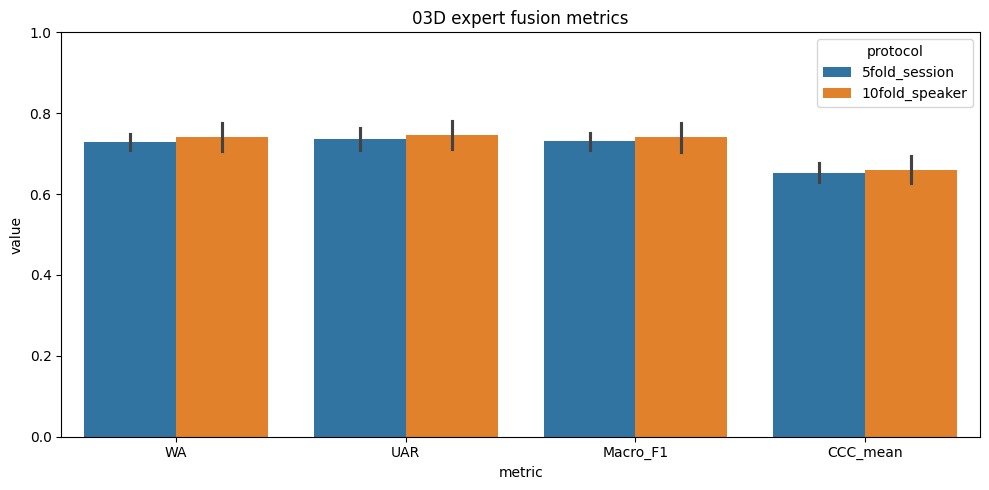

Saved: /kaggle/working/output_03d_03b_03c_expert_fusion/figures/03D_metric_summary.png


In [9]:
if len(results_df):
    metric_cols = ["WA", "UAR", "Macro_F1", "Weighted_F1", "CCC_valence", "CCC_arousal", "CCC_dominance", "CCC_mean", "MAE_mean", "RMSE_mean"]
    summary = results_df.groupby("protocol")[metric_cols].agg(["mean", "std"]).reset_index()
    summary.to_csv(REPORT_DIR / "03D_03B_03C_expert_fusion_summary.csv", index=False)
    display(summary)

    paper_rows = []
    for protocol, sub in results_df.groupby("protocol"):
        row = {"Protocol": protocol, "Folds": len(sub)}
        for col in metric_cols:
            mean = sub[col].mean()
            std = sub[col].std(ddof=1) if len(sub) > 1 else 0.0
            if col in ["WA", "UAR", "Macro_F1", "Weighted_F1"]:
                row[col] = f"{mean*100:.2f} +/- {std*100:.2f}"
            else:
                row[col] = f"{mean:.3f} +/- {std:.3f}"
        paper_rows.append(row)
    paper_df = pd.DataFrame(paper_rows)
    paper_df.to_csv(REPORT_DIR / "03D_paper_style_results.csv", index=False)
    display(paper_df)

    if plt is not None:
        plot_df = results_df.melt(id_vars=["protocol", "fold"], value_vars=["WA", "UAR", "Macro_F1", "CCC_mean"], var_name="metric", value_name="value")
        plt.figure(figsize=(10, 5))
        sns.barplot(data=plot_df, x="metric", y="value", hue="protocol", errorbar="sd")
        plt.ylim(0, 1)
        plt.title("03D expert fusion metrics")
        plt.tight_layout()
        fig_path = FIGURE_DIR / "03D_metric_summary.png"
        plt.savefig(fig_path, dpi=160)
        plt.show()
        print("Saved:", fig_path)
else:
    print("Không có fold nào chạy được. Xem reports/03D_missing_feature_folds.csv để biết thiếu file nào.")


In [10]:
config = {
    "notebook": "03D 03B acoustic expert + 03C tuned script expert fusion",
    "model_variant": MODEL_VARIANT,
    "reusable_model_folder": str(MODEL_DIR.relative_to(OUTPUT_DIR)),
    "run_protocols": RUN_PROTOCOLS,
    "allow_text_only_fallback": ALLOW_TEXT_ONLY_FALLBACK,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "loss": {
        "ce_weight": CE_WEIGHT,
        "ccc_weight": CCC_WEIGHT,
        "mse_weight": MSE_WEIGHT,
    },
    "upload_required": {
        "03B": "fusion_features/*_coattention_features.npz for 5-fold; for missing 10-fold, upload notebook 02 cache and this notebook can train internal 03B-style acoustic expert",
        "03C": "fusion_features/*_text_features.npz for every protocol/fold/split you want to test",
        "notebook_02_for_internal_10fold": "features/iemocap_full_06d_multibranch_cache.npz and splits/iemocap_10fold_speaker_long.csv",
        "model_outputs": "models_acoustic_plus_tuned_script/<protocol>/*_acoustic_plus_tuned_script_fusion_best.pt",
        "not_required_for_training_this_fusion": "pretrained model weights, because 03D consumes exported expert features",
    },
}
(REPORT_DIR / "03D_run_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")

manifest = []
for folder in [REPORT_DIR, FIGURE_DIR, PRED_DIR, MODEL_DIR, INTERNAL_03B_FUSION_DIR]:
    for p in folder.rglob("*"):
        if p.is_file():
            manifest.append({"relative_path": str(p.relative_to(OUTPUT_DIR)), "bytes": p.stat().st_size})
manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(REPORT_DIR / "output_manifest.csv", index=False)
display(manifest_df)

zip_path = OUTPUT_DIR.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [REPORT_DIR, FIGURE_DIR, PRED_DIR, MODEL_DIR, INTERNAL_03B_FUSION_DIR]:
        for p in folder.rglob("*"):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR))
model_zip_path = OUTPUT_DIR / "03D_models_acoustic_plus_tuned_script.zip"
with zipfile.ZipFile(model_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in MODEL_DIR.rglob("*"):
        if p.is_file():
            z.write(p, p.relative_to(OUTPUT_DIR))
print("Saved zip:", zip_path)
print("Saved model zip:", model_zip_path)


,relative_path,bytes
0,reports/10fold_speaker_fold_4_test_Ses02M_val_...,4414
1,reports/10fold_speaker_fold_9_test_Ses05F_val_...,1443
2,reports/10fold_speaker_fold_2_test_Ses01M_val_...,3910
3,reports/10fold_speaker_fold_10_test_Ses05M_val...,3640
4,reports/10fold_speaker_fold_5_test_Ses03F_val_...,1677
...,...,...
72,internal_03b_acoustic/fusion_features/10fold_s...,478549
73,internal_03b_acoustic/fusion_features/10fold_s...,500142
74,internal_03b_acoustic/fusion_features/10fold_s...,586086
75,internal_03b_acoustic/fusion_features/10fold_s...,646268


Saved zip: /kaggle/working/output_03d_03b_03c_expert_fusion.zip
